<a href="https://colab.research.google.com/github/SteTerro/Mail-Classifier/blob/main/mail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classification: *Spam Email Dataset*

E-mail are keypoints of communication in today's technological landscape. Consequently, the ability to classify them accurately and, specifically to filter out spam to prevent inbox congestion, is of big importance.
This project evaluates and compares four distinct models:

- SVC (Support Vector Classification)
- Decision Trees
- Random Forest
- Neural Networks

The primary objective is to identify the model that offers the best predictive performance while maintaining a low memory footprint. Resource efficiency is a critical pointr, as the infrastructures hosting these models (such as IoT devices) often have limited hardware resources. These resources must be shared across multiple functions and cannot be entirely dedicated to e-mail filtering.

The notebook is organized into the following sections:

1. Pre-processing and Utility
2. Defining Error Metrics
3. SVM (Support Vector Machine)
4. Decision Trees
5. Random Forest
6. Multi Layer Perceptron
7. Alternative SVM
8. Conclusion and Additional Notes

> **NOTE:**
> Given Google Colab's limited resources, this is a "reduced" version (especially for training) of the original notebook. The original notebook, with a pre-compiled version, has been uploaded along with this activity.

## 1. Pre-processing and Utility

The project begins by importing the required libraries:
- *ucimlrepo:* used to download the dataset directly from the UCI repository;
- *time:* used to measure and compare the inference time of each model;
- *scikit-learn:* the library used for loading machine learning models and performing hyperparameter tuning.
- *pympler:* utilized to calculate the memory footprint of the models, ensuring they meet the constraints of resource-limited environments.

In [ ]:
!pip install ucimlrepo
!pip install pympler

from ucimlrepo import fetch_ucirepo

import numpy as np
import pandas as pd
import time
import warnings
from pympler import asizeof
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')

Ther first function we define is to generate a scatterplot for model comparison. This chart will visualize the trade-off between performance and efficiency:

- The Y-axis will display the F1-Score, representing the model's balanced predictive accuracy.

- The X-axis will display the memory footprint, highlighting the model's impact on system resources.

This visualization aim to identify which model achieve the optimal balance between accuracy and weight.

In [ ]:
def scatterplot(results):
  df = pd.DataFrame(results)

  plt.figure(figsize=(12, 7))
  scatter = plt.scatter(df["Peso (KB)"], df["F1-Score (%)"],
                        c=df["F1-Score (%)"], cmap='viridis',
                        s=100, edgecolors='black')

  plt.colorbar(scatter, label='F1-Score (%)')

  for i in range(len(df)):
      plt.annotate(df["Model"].iloc[i],
                  (df["Peso (KB)"].iloc[i], df["F1-Score (%)"].iloc[i]),
                  xytext=(5, 5), textcoords='offset points', fontsize=8)

  plt.xlabel("RAM Weight (KB)")
  plt.ylabel("F1-Score (%)")
  plt.title(f"Trade-off Scatterplot")
  plt.grid(True, alpha=0.3)
  plt.show()

The second function visualizes the Confusion Matrix for each model. This visualization is essential for evaluating the nature of the classifier's errors.

A confusion matrix compares the actual labels with the predicted ones. It is made of 4 categories:

- *True Positives (TP):* Spam emails correctly identified as spam;

- *True Negatives (TN):* Legitimate emails correctly identified as not spam;

- *False Positives (FP):* Legitimate emails mistakenly flagged as spam;

- *False Negatives (FN):* Spam emails that go undetected;

In this context, the most critical categorie is the False Positives (FP). While a False Negative (a spam email reaching the inbox) is a minor nuisance, a False Positive is more concerning.

Given that, our goal is to minimize False Positives to ensure the reliability of the filter.

In [ ]:
def confusionematrix(models, w_test, z_test):
  n_models = len(models)
  n_cols = 11  # 3 modelli per riga
  n_rows = (n_models + n_cols - 1) // n_cols

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
  axes = axes.flatten() if n_models > 1 else [axes]

  print(f"\nConfusion MAtrix {n_models} modelli:")

  for idx, (n_features, model) in enumerate(models.items()):
      pred = model.predict(w_test)
      cm = confusion_matrix(z_test, pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm)
      disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
      axes[idx].set_title(f"{n_features} features")

  for idx in range(n_models, len(axes)):
      axes[idx].set_visible(False)

  plt.tight_layout()
  plt.suptitle("Confusion Matrix - Model Comparison", y=1.02, fontsize=14)
  plt.show()

# Evaluation Metrics

To evaluate the models performance and their ability to distinguish between legitimate emails and spam, we will use the following statistical metrics:

*Accuracy:* the proportion of correct predictions (both positive and negative) out of the total number of cases:

$A = \frac{TP + TN}{TP + TN + FP + FN}$

*Precision:* the model's reliability in identifying spam by calculating the ratio of true positives to the total number of positive predictions:

$P = \frac{TP}{TP + FP}$

*F1-Score:* the harmonic mean between precisiona and recall. Is a balanced assessment of the model's discriminatory power:

$F1 = 2 * \frac{P \times R}{P + R} $

Where *Recall (R)* is defined as the model's ability to identify all actual spam messages:

$R = \frac{TP}{TP +FN }$

The `training` function wil be used for models training. It takes in input:
- *model:* the base model;
- *param_grid:* the param grid associated with that model;
- X_train, y_train, X_test, y_test dataset for training and validation;
- *feature_reange:* the number of feature in a dataset as a list.

The `training` offers various feature:

- *Scaling and Feature Selection:* for each value in *feature_range*, the function selects the top k features using `SelectKBest`. This is important for evaluating how the number of features impacts the final memory footprint.

- *Hyperparameter Optimization:* it uses GridSearchCV to identify the optimal model configuration within the provided parameter grid.

- *Resource Monitoring:*

  - Time: it measures the duration of both the fitting and inference processes.

  - Memory: it uses `pympler.asizeof` to calculate the actual memory weight (in KB) of the best estimator found.

> The function is designed to take models other than those used in this notebook, although these will not have VERBOSE printouts.

In [ ]:
def training(model, param_grid, X_train, y_train, X_test, y_test, feature_range, VERBOSE = False):
    models = {}
    results = []

    if isinstance(model, SVC):
        classifier = "SVM"
    elif isinstance(model, DecisionTreeClassifier):
        classifier = "DecisionTree"
    elif isinstance(model, RandomForestClassifier):
        classifier = "RandomForest"
    elif isinstance(model, MLPClassifier):
        classifier = "MLP"
    else:
        classifier = "Other"

    for f in feature_range:

        base_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('selector', SelectKBest(f_classif, k=f)),
            # ('model', classifier)
            ('model', model)
        ])

        grid = GridSearchCV(base_pipeline, param_grid, cv=5, n_jobs=-1)

        start_time = time.time()
        grid.fit(X_train, y_train)
        predictions = grid.predict(X_test)
        end_time = time.time()

        report = classification_report(y_test, predictions, output_dict=True)
        acc = report['accuracy']
        f1 = report['weighted avg']['f1-score']
        # precision = report['weighted avg']['precision']

        size_kb = asizeof.asizeof(grid.best_estimator_) / 1024

        models[f] = grid.best_estimator_

        results.append({
            "Model": f,
            "Accuratezza (%)": round(acc * 100, 2),
            "F1-Score (%)": round(f1 * 100, 2),
            "Peso (KB)": round(size_kb, 2),
            "Tempo (s)": round(end_time - start_time, 4)
        })

        if VERBOSE:
            if classifier == "SVM":
                print(f"feature {f}, C = {models[f]['model'].C}, kernel = {models[f]['model'].kernel}, F1: {round(f1,3)}, Memory: {round(size_kb, 2)}")
            elif classifier == "RandomForest":
                print(f"feature {f}, n_estimators = {models[f]['model'].n_estimators}, max_depth = {models[f]['model'].max_depth}, F1: {round(f1,3)}, Memory: {round(size_kb, 2)}")
            elif classifier  == "DecisionTree":
                print(f"feature {f}, depth = {models[f]['model'].max_depth}, F1: {round(f1,3)}, Memory: {round(size_kb, 2)}")
            elif classifier == "MLP":
                print(f"feature {f}, hidden_layer_sizes = {models[f]['model'].hidden_layer_sizes}, alpha = {models[f]['model'].alpha}, F1: {round(f1,3)}, Memory: {round(size_kb, 2)}")
            elif classifier == "Other":
                print(f"feature {f}, F1: {round(f1,3)}, Memory: {round(size_kb, 2)}")
    return results, models

The dataset is imported directly from the official *UC Irvine Machine Learning Repository*. After the download, we perform a preliminary visualization of the data and its labels to verify the structure.

The classification target is binary:

- *Value 1:* denotes e-mails classified as Spam.
- *Value 0:* denotes legitimate e-mails.

In [ ]:
# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets
# metadata
# print(spambase.metadata)
print(X.head())
print(y.head())
# variable information
# print(spambase.variables)

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  word_freq_conference  char_freq_;  \
0             0.00            0.00  ...                   0.0 

### Data Cleaning

We clean the dataset. Specifically:

- We remove any missing values (NaN);

- We drop columns containing only zero values.

> **NOTE:**  Although the main UCI repository page mentions the presence of missing values, a closer look at the Variables Table on the same page suggests that the features may not contain any. Despite this ambiguity, we still clean the data to prevent errors during training.

In [ ]:
X = X.dropna()
X = X.loc[:, (X != 0).any(axis=0)]

print()

y = y.values.ravel()
print(y)
# print(f"NaN in X: {X.isnull().sum()}")


[1 1 1 ... 0 0 0]


The dataset is partitioned into three distinct sets:

- *Training Set (60%):* Used for the actual training of the algorithms.

- *Validation Set (20%):* Employed during the training phase for hyperparameter tuning and to prevent overfitting.

- *Test Set (20%):* Reserved for the final evaluation. This set allows us to compare the performance of the different models.

We also define the feature list that will be used as input for the classifiers

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) # 0.25 x 0.8 = 0.2

feature_range = list(range(1, 58))

## SVM

The first model tested is the *Support Vector Machine (SVM)*. This supervised learning algorithm aims to find the optimal hyperplane that maximizes the separation margin between classes (in this case, Spam and legi emails).

To optimize the model, we define a parameter grid for GridSearchCV. Since the linear kernel showed poor performance in preliminary trials, it's been decided to implement the RBF (Radial Basis Function) kernel. This non-linear approach maps the data into a higher-dimensional space, providing greater flexibility.

In [ ]:
svm_grid = {
    'model__C': [1, 3, 5, 7],
    'model__kernel': ['rbf']
}

model = SVC()

Instead of training a single static model using the full feature set, an incremental training strategy based on the number of features was adopted. The process involves running iterative cycles, varying the number of features from 1 up to the maximum available (57).

In [ ]:
svm_result, svm_models = training(model, svm_grid, X_train, y_train, X_val, y_val, feature_range, VERBOSE=True)

feature 1, C = 1, kernel = rbf, F1: 0.752, Memory: 48.16
feature 2, C = 3, kernel = rbf, F1: 0.796, Memory: 53.0
feature 3, C = 1, kernel = rbf, F1: 0.803, Memory: 57.28
feature 4, C = 5, kernel = rbf, F1: 0.849, Memory: 56.98
feature 5, C = 5, kernel = rbf, F1: 0.877, Memory: 55.65
feature 6, C = 5, kernel = rbf, F1: 0.869, Memory: 63.36
feature 7, C = 3, kernel = rbf, F1: 0.874, Memory: 69.69
feature 8, C = 1, kernel = rbf, F1: 0.9, Memory: 77.83
feature 9, C = 5, kernel = rbf, F1: 0.904, Memory: 75.97
feature 10, C = 5, kernel = rbf, F1: 0.906, Memory: 76.77
feature 11, C = 7, kernel = rbf, F1: 0.898, Memory: 82.39
feature 12, C = 7, kernel = rbf, F1: 0.898, Memory: 88.05
feature 13, C = 3, kernel = rbf, F1: 0.887, Memory: 99.78
feature 14, C = 3, kernel = rbf, F1: 0.89, Memory: 103.99
feature 15, C = 3, kernel = rbf, F1: 0.899, Memory: 107.88
feature 16, C = 3, kernel = rbf, F1: 0.903, Memory: 116.33
feature 17, C = 5, kernel = rbf, F1: 0.908, Memory: 117.51
feature 18, C = 5, kern

Among the various configurations, the model with 10 features was selected. This version ensures a strong predictive capability (F1-Score = 0.906) while maintaining an extremely low memory footprint of approximately 77 KB. In contrast, models with a higher number of features, despite offering slight accuracy improvements, see their size swell up to 400 KB, making them less suitable for deployment on hardware-constrained devices.

> **NOTE:** A significantly higher memory consumption is observed compared to future models. This increase is caused by SVM algorithm, which stores support vectors directly tied to the feature dimensionality.

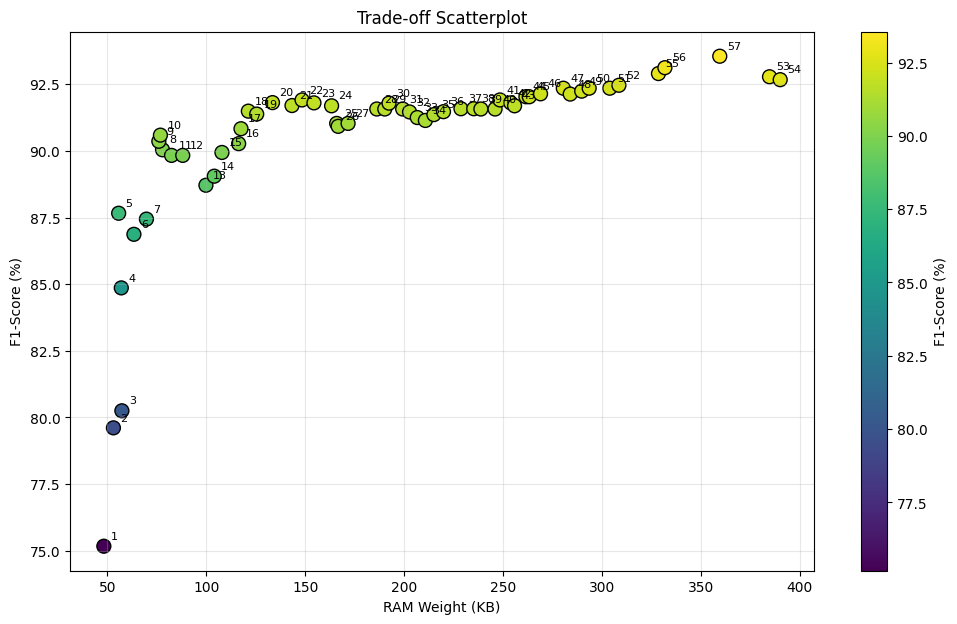


Confusion MAtrix 57 modelli:


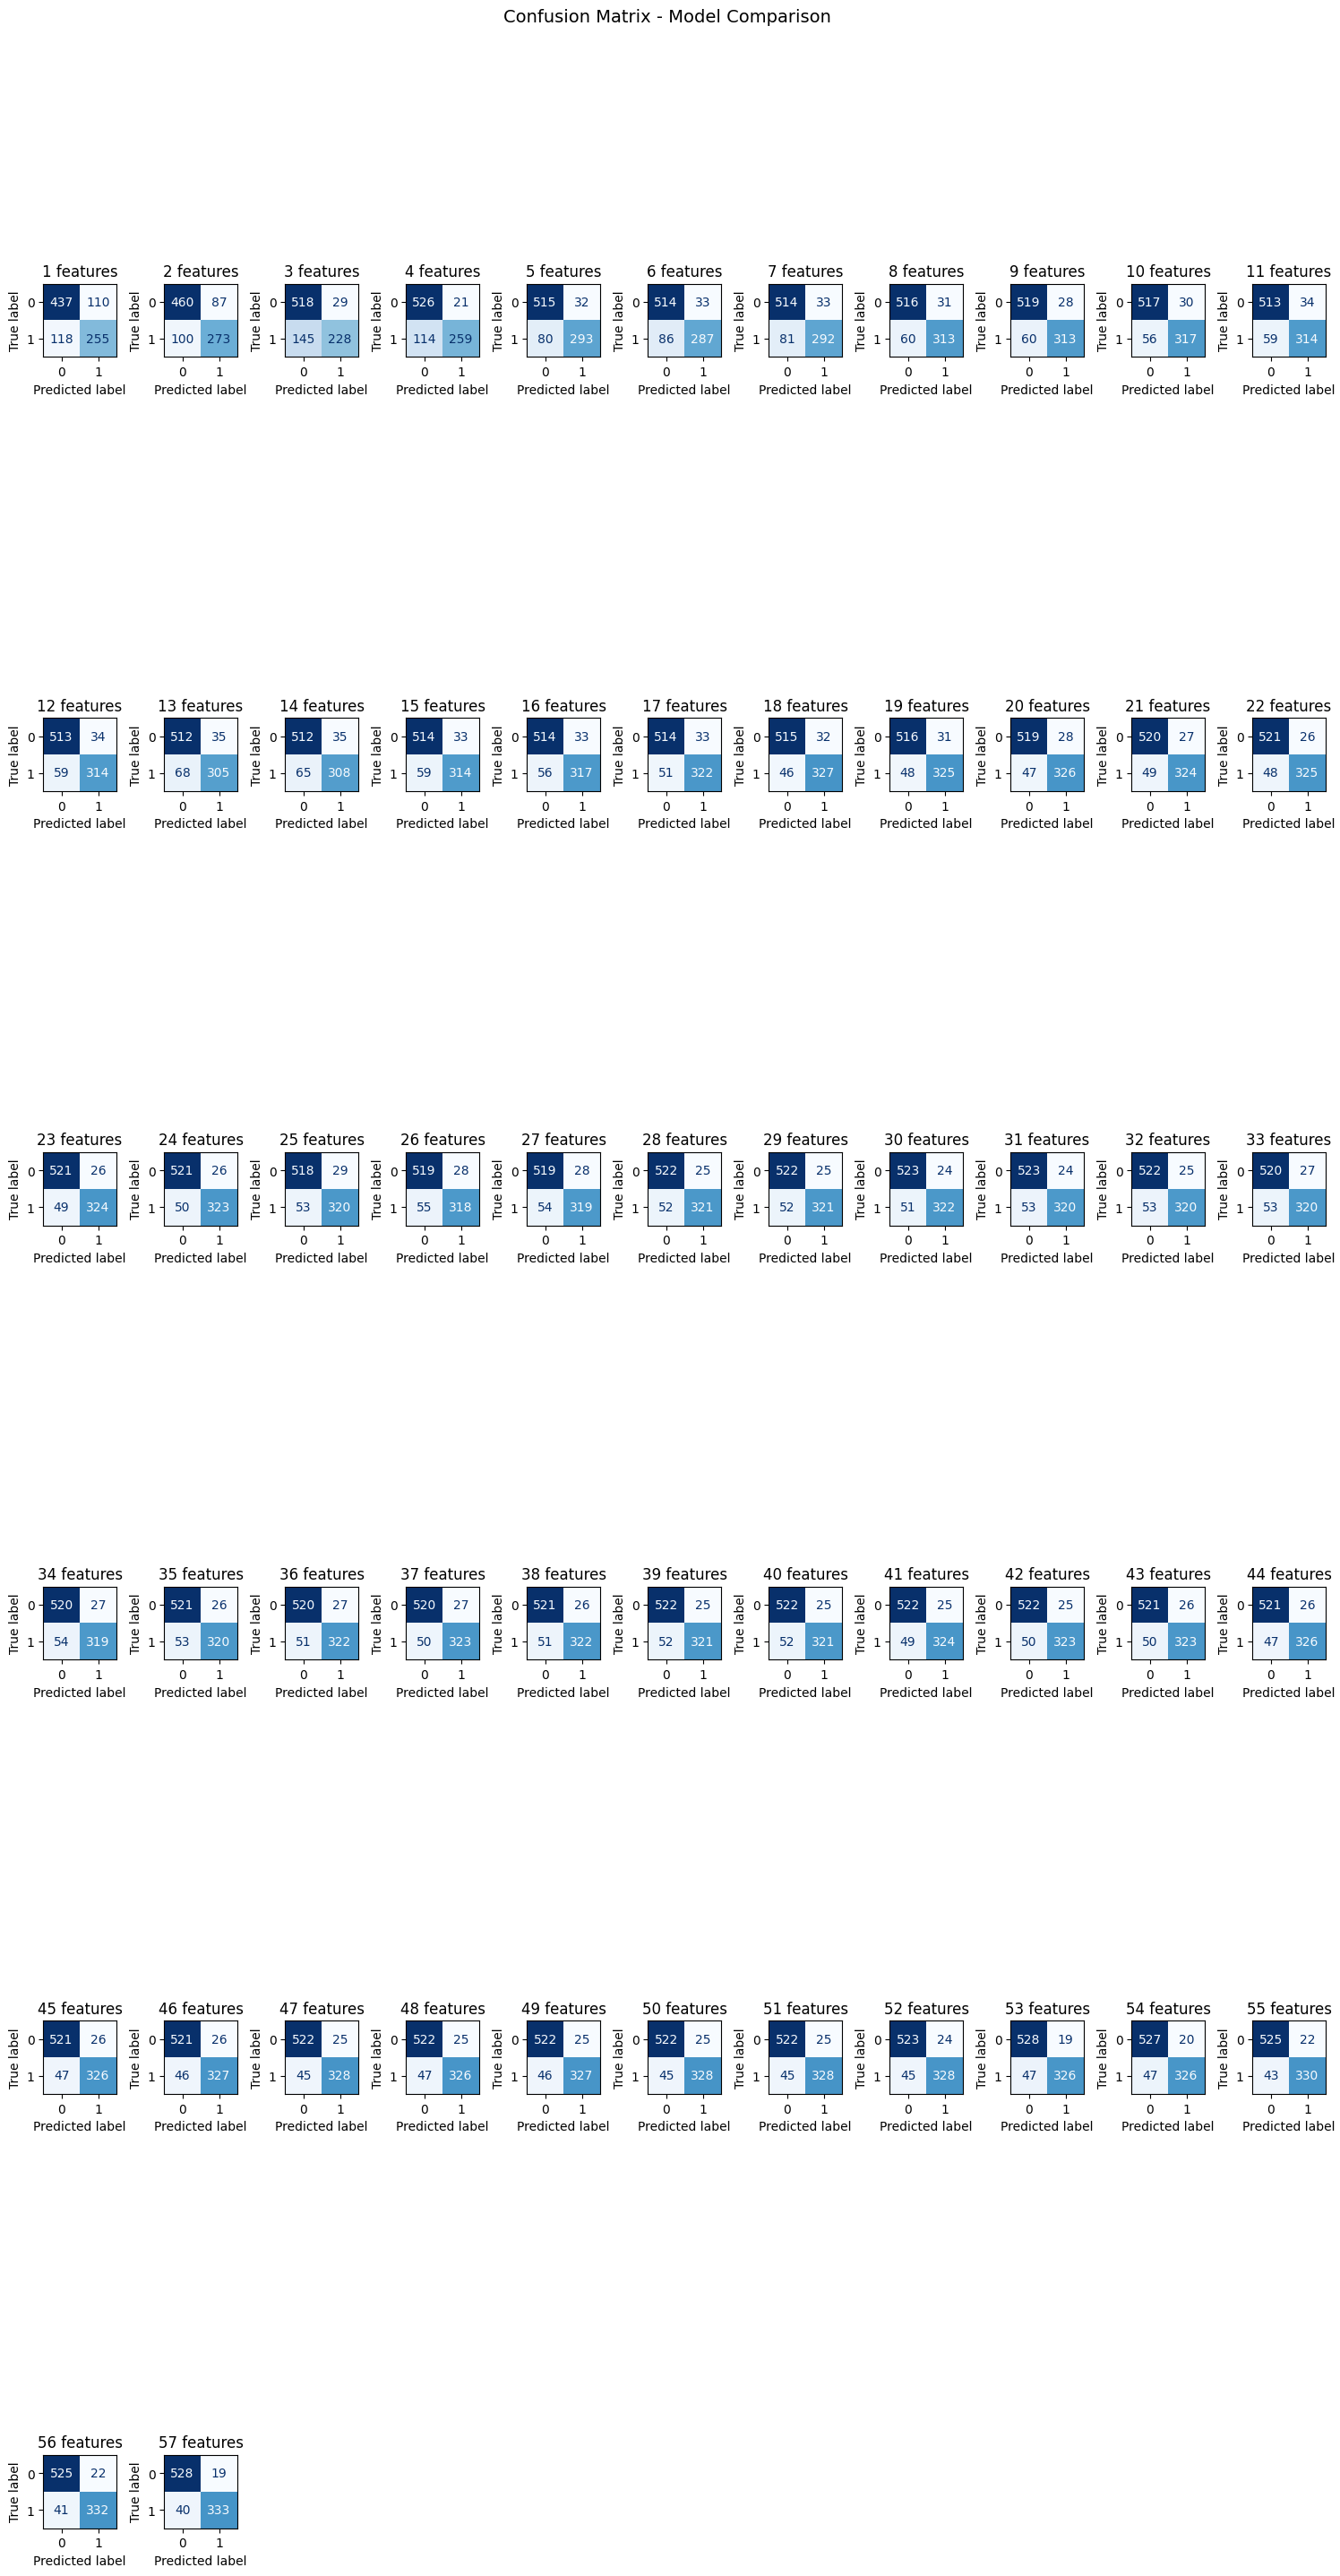

In [ ]:
scatterplot(svm_result)
confusionematrix(svm_models, X_val, y_val)

The model with 10 feature has 30 false negatives and 56 false positives.

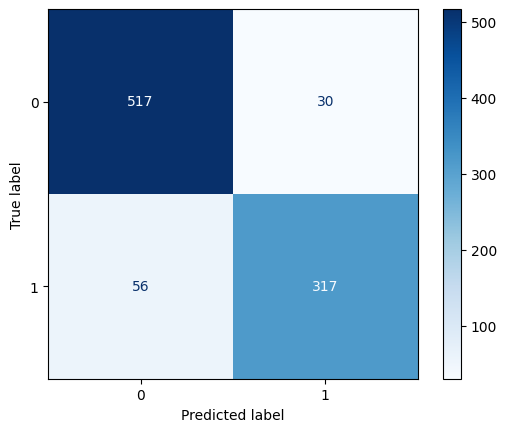

In [ ]:
svm = svm_models[10]

predictions = svm.predict(X_val)

ConfusionMatrixDisplay.from_estimator(svm, X_val, y_val, cmap='Blues')
plt.show()

## Alberi

The second model analyzed is the Decision Tree. This algorithm builds a predictive model with a hierarchical graph structure.

Decision trees are particularly advantageous due their computational efficiency. They usually require very little processing power during inference and have a very small memory usage.

In [ ]:
tree_params = {
    # 1, 3, 5, 7, 9, 11, 13, 15
    'model__max_depth': [1, 3, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

model = DecisionTreeClassifier()

Training the model

In [ ]:
tree_results, tree_models = training(model, tree_params, X_train, y_train, X_val, y_val, feature_range, VERBOSE=True)

feature 1, depth = 1, F1: 0.755, Memory: 8.41
feature 2, depth = 3, F1: 0.79, Memory: 8.44
feature 3, depth = 5, F1: 0.789, Memory: 8.47
feature 4, depth = 5, F1: 0.86, Memory: 8.47
feature 5, depth = 5, F1: 0.874, Memory: 8.44
feature 6, depth = 5, F1: 0.872, Memory: 8.47
feature 7, depth = 5, F1: 0.876, Memory: 8.5
feature 8, depth = 5, F1: 0.893, Memory: 8.5
feature 9, depth = 5, F1: 0.897, Memory: 8.5
feature 10, depth = 5, F1: 0.888, Memory: 8.47
feature 11, depth = 5, F1: 0.888, Memory: 8.47
feature 12, depth = 5, F1: 0.885, Memory: 8.47
feature 13, depth = 5, F1: 0.884, Memory: 8.47
feature 14, depth = 5, F1: 0.889, Memory: 8.47
feature 15, depth = 5, F1: 0.894, Memory: 8.47
feature 16, depth = 5, F1: 0.895, Memory: 8.47
feature 17, depth = 5, F1: 0.894, Memory: 8.44
feature 18, depth = 5, F1: 0.893, Memory: 8.47
feature 19, depth = 5, F1: 0.906, Memory: 8.44
feature 20, depth = 5, F1: 0.904, Memory: 8.47
feature 21, depth = 5, F1: 0.906, Memory: 8.47
feature 22, depth = 5, F1: 

Analysis of the scatterplot reveals a clear grouping of the models into three main clusters based on memory footprint (four, if we consider the outlier case of the single-feature model). It is noteworthy that all Decision Tree models maintain a very consistent memory weight across the board been between 8.38 and 8.46Kb, which is extremely low.

The optimal model is the one trained with 54 and 55 features. They have the same F1-Score, but the model with 54 feature is a little bit lighter so this model is preferred. Noteworthy is that this configuration not only ensures a small memory footprint but paradoxically demonstrates higher accuracy than models with a larger feature count.

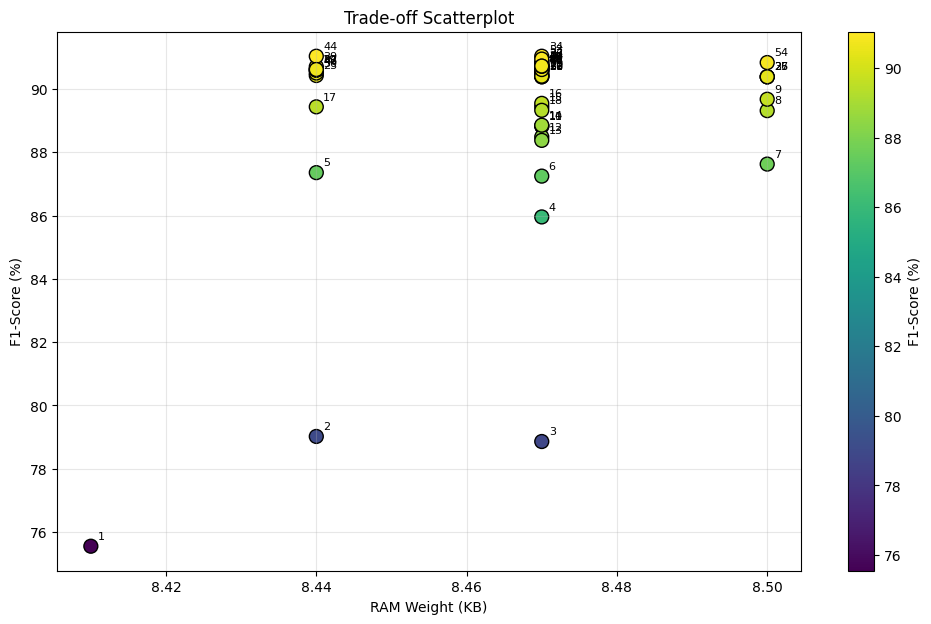


Confusion MAtrix 57 modelli:


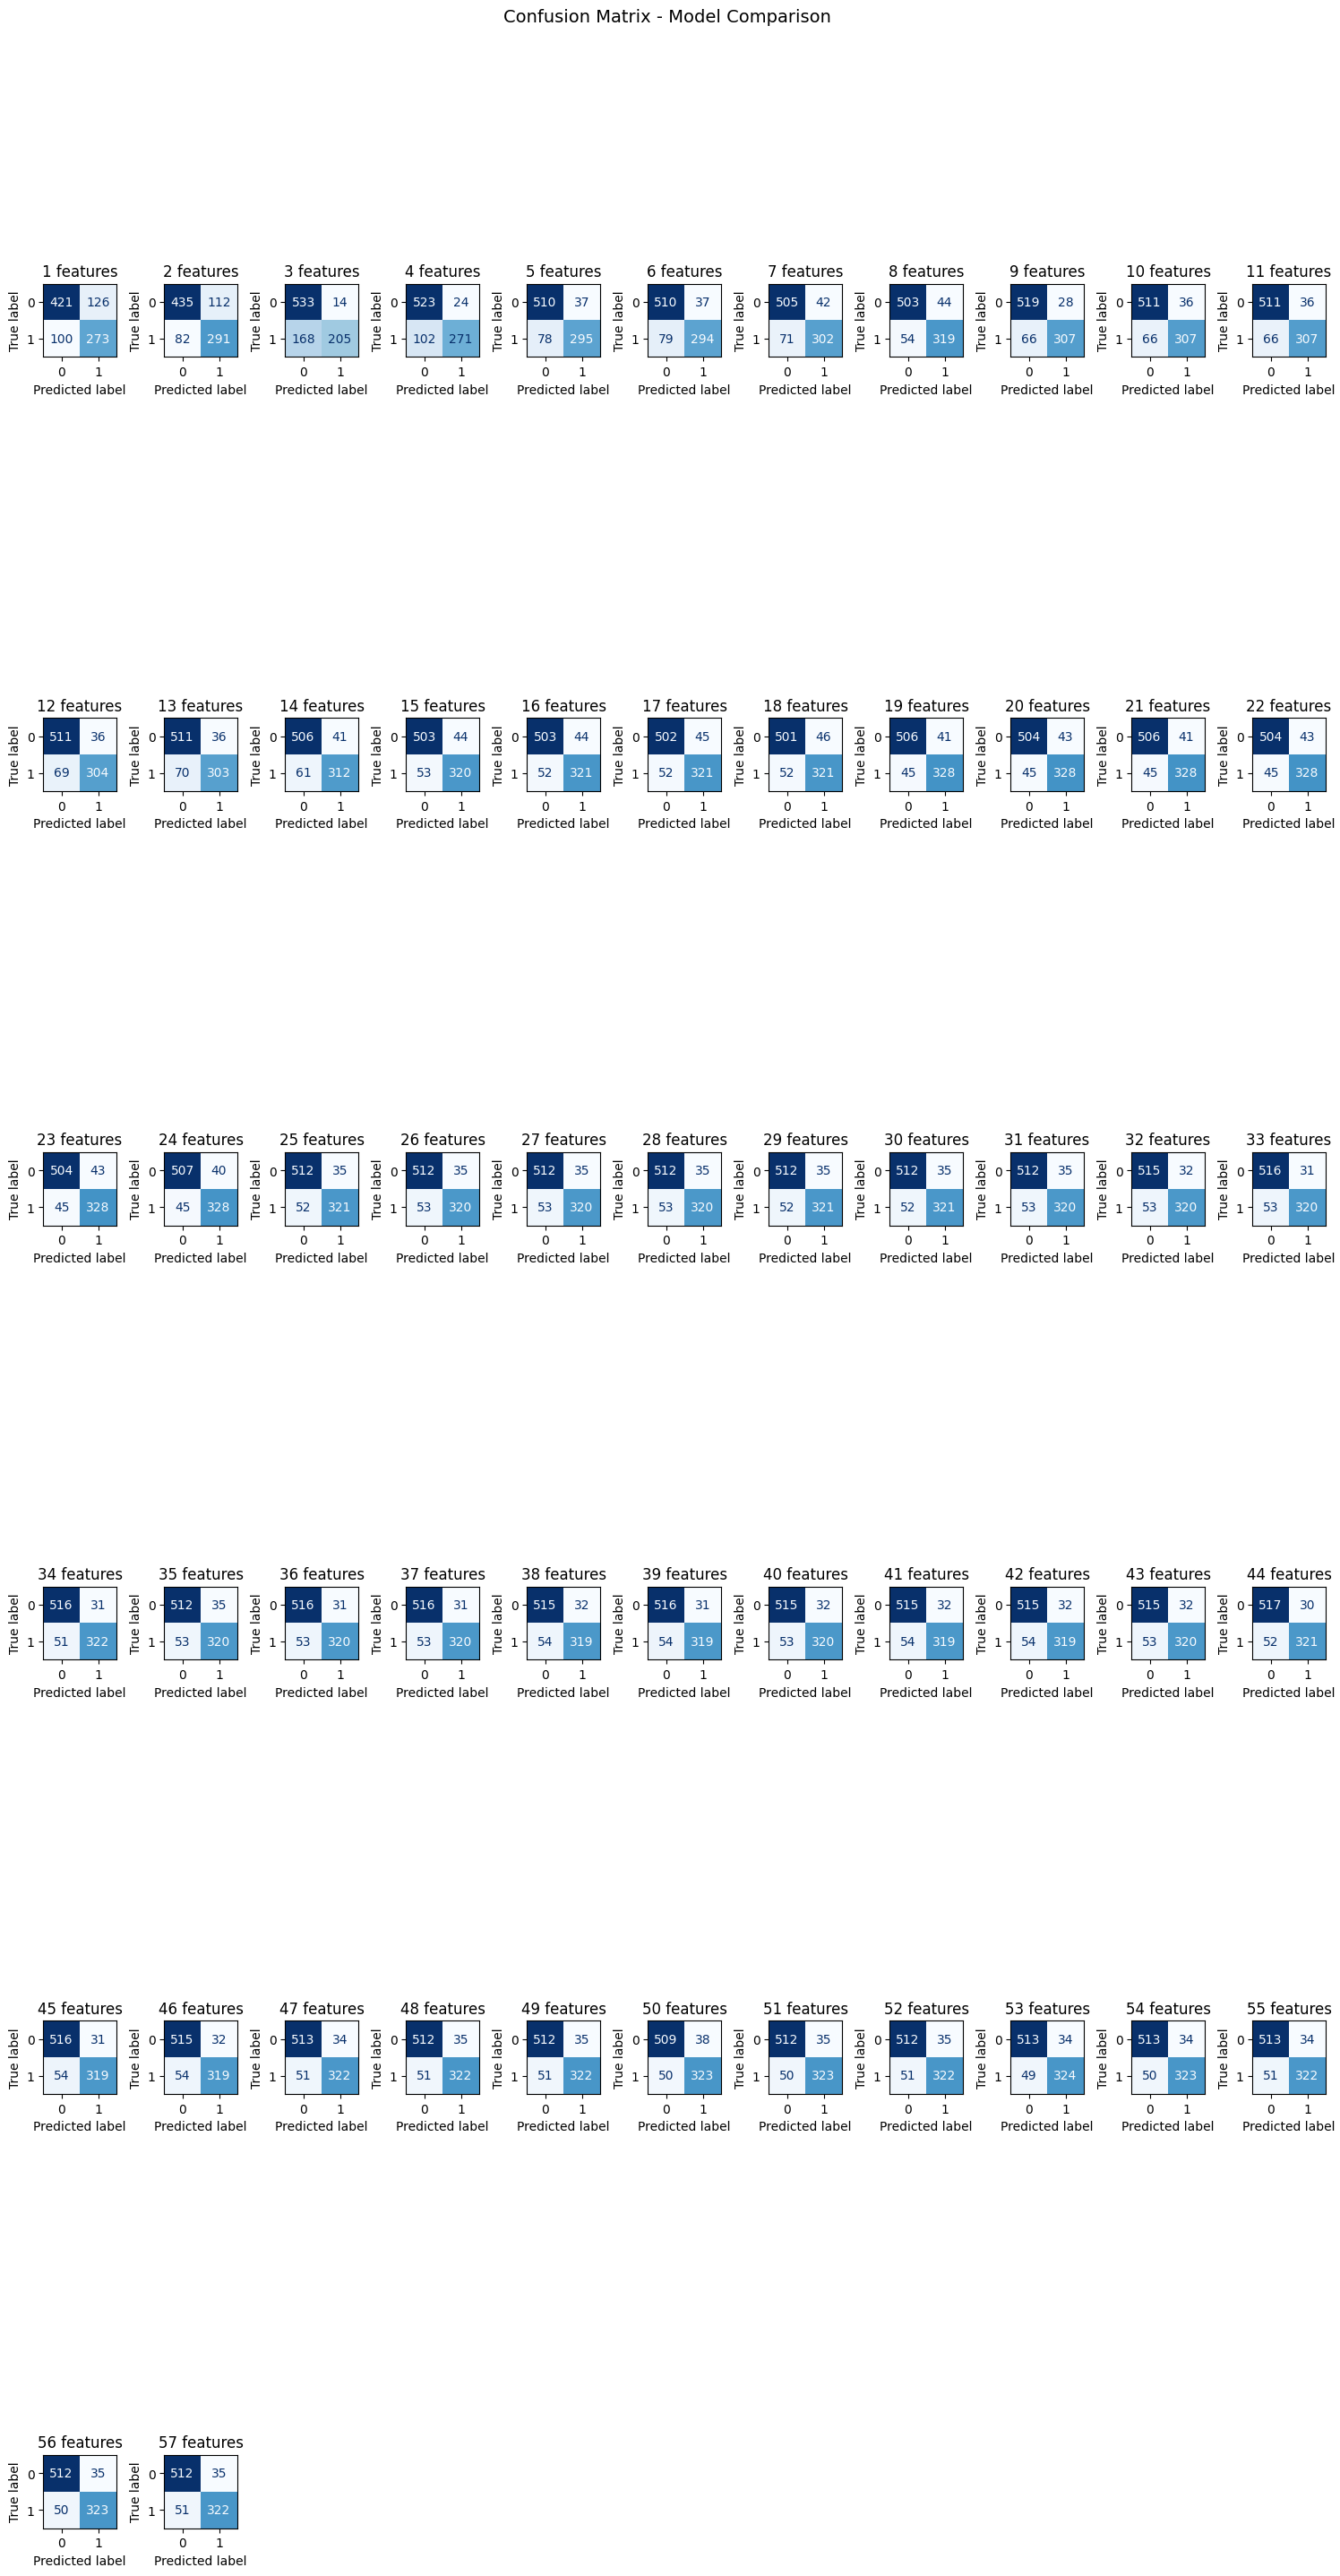

In [ ]:
scatterplot(tree_results)
confusionematrix(tree_models, X_val, y_val)

The model seems to have high Recall with only 34 false negatives compared to 513 True Positives, the model is highly effective at detecting spam. Most unsolicited emails are correctly blocked.
Unfortunately, there are 48 egitimate emails wrongly classified as spam so the number of false positives is quite high.

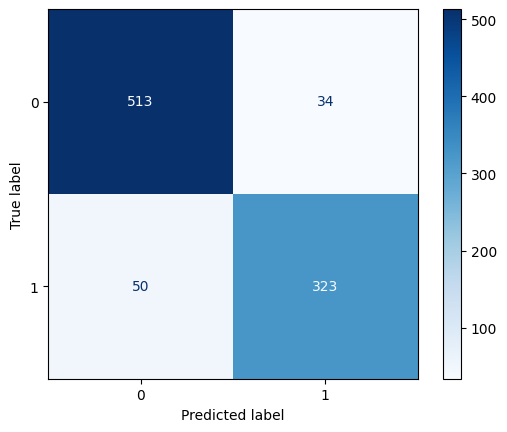

In [ ]:
tree = tree_models[54]
ConfusionMatrixDisplay.from_estimator(tree, X_val, y_val, cmap='Blues')
plt.show()

## Random Forest

Given the excellent results achieved with the single Decision Tree, we decided to test the Random Forest model. This algorithm operates by constructing a "forest" of decision trees trained on different subsets of the data.

Given that, he Random Forest will inevitably lead to an increased memory footprint compared to a single estimator. Nevertheless, the goal of this test is to determine whether the performance gains in F1-Score justify the higher resource consumption. WE will focus on finding an acceptable trade-off between the number of estimators (n_estimators) and the model's compactness.

In [ ]:
results = []
models = {}

rf_params = {
    'model__n_estimators': [10, 20, 30],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_leaf': [2, 5]
}

model = RandomForestClassifier()

In [ ]:
rf_results, rf_models = training(model, rf_params, X_train, y_train, X_val, y_val, feature_range, VERBOSE=True)

feature 1, n_estimators = 10, max_depth = 5, F1: 0.751, Memory: 21.86
feature 2, n_estimators = 20, max_depth = 15, F1: 0.788, Memory: 33.45
feature 3, n_estimators = 30, max_depth = 15, F1: 0.797, Memory: 45.02
feature 4, n_estimators = 30, max_depth = 10, F1: 0.864, Memory: 45.02
feature 5, n_estimators = 30, max_depth = 10, F1: 0.893, Memory: 45.02
feature 6, n_estimators = 20, max_depth = 10, F1: 0.893, Memory: 33.45
feature 7, n_estimators = 30, max_depth = 15, F1: 0.899, Memory: 45.02
feature 8, n_estimators = 30, max_depth = 10, F1: 0.912, Memory: 45.02
feature 9, n_estimators = 20, max_depth = 15, F1: 0.907, Memory: 33.48
feature 10, n_estimators = 30, max_depth = 10, F1: 0.918, Memory: 45.02
feature 11, n_estimators = 30, max_depth = 15, F1: 0.918, Memory: 45.05
feature 12, n_estimators = 20, max_depth = 15, F1: 0.916, Memory: 33.48
feature 13, n_estimators = 20, max_depth = 15, F1: 0.92, Memory: 33.48
feature 14, n_estimators = 20, max_depth = 15, F1: 0.923, Memory: 33.48
fea

The model, as expected, show behavior similar to Decision Trees, with model creating two main clusters. The optimal configuration is the model with 53 features, which achieves an F1-Score of 0.937 with a memory footprint of approximately 33 KB. While the Random Forest is heavier than a single tree, the performance gain in terms of accuracy is significant, justifying the increase in memory usage.

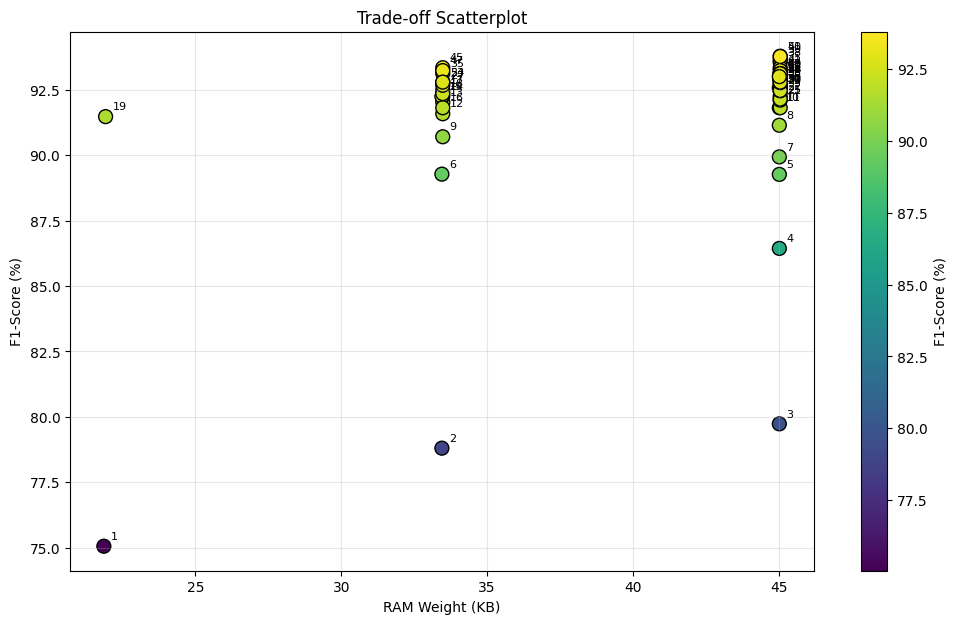


Confusion MAtrix 57 modelli:


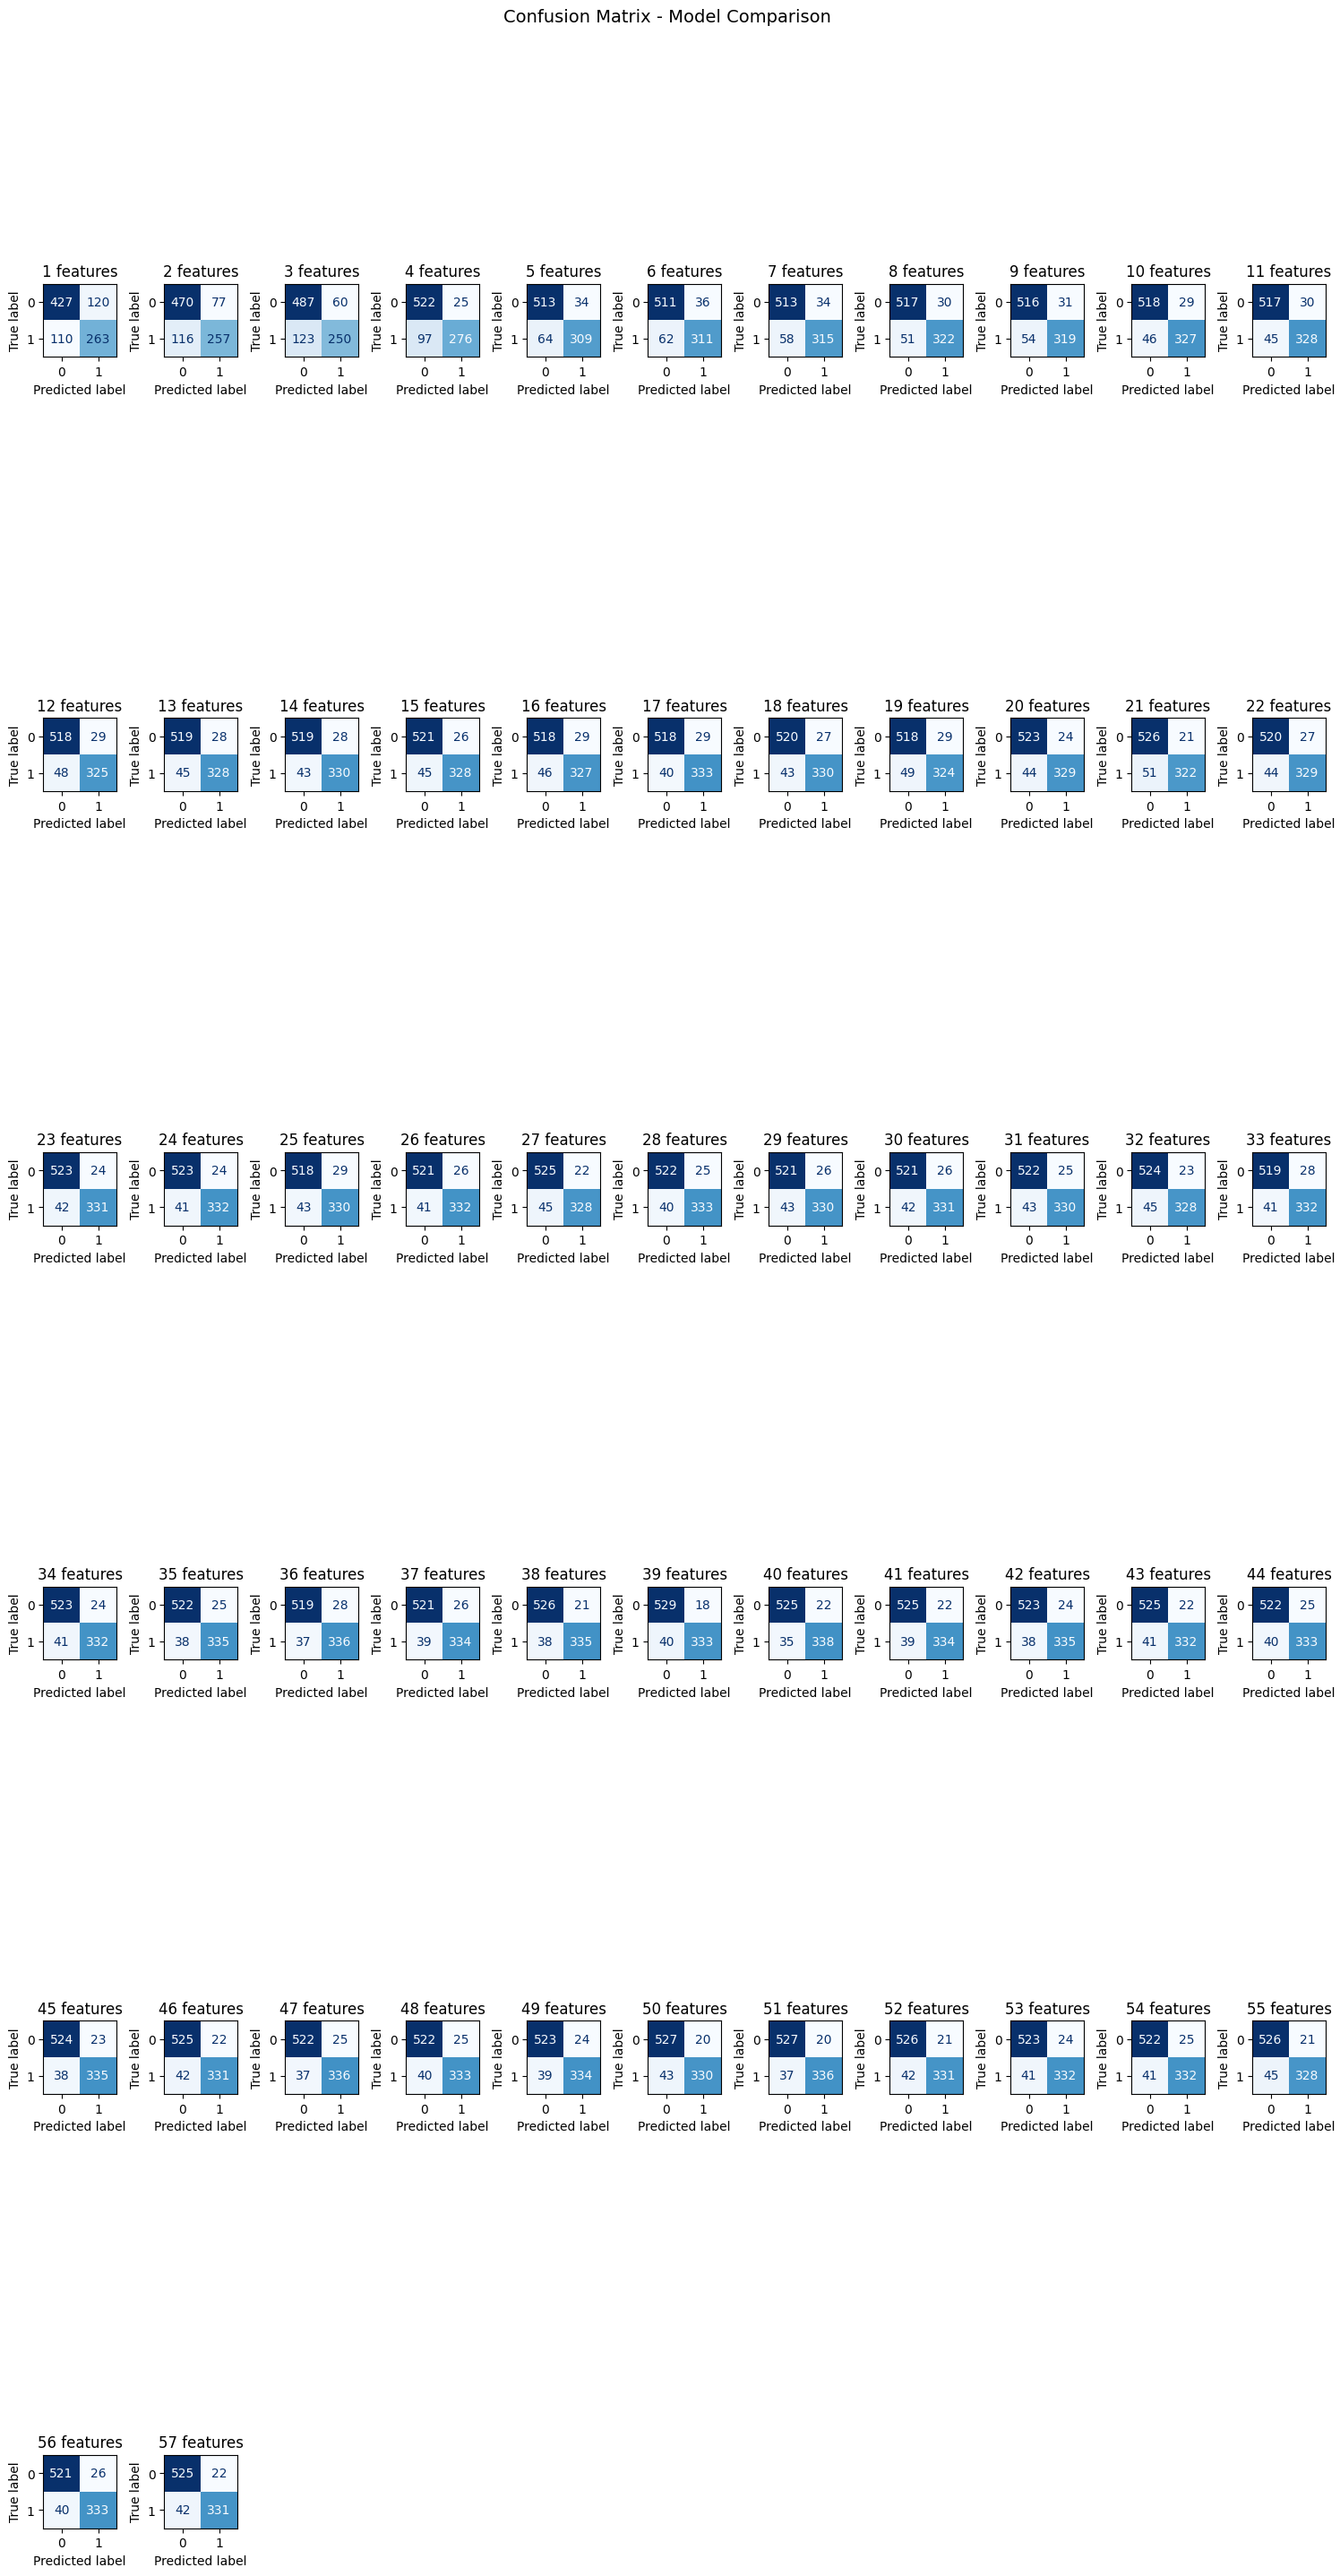

In [ ]:
scatterplot(rf_results)
confusionematrix(rf_models, X_val, y_val)

As the previous model, the random forest has a great recall with only 20 false negatives. The False positives are less than previous models but still not the best.

Modello selezionato (43 feature): Pipeline(steps=[('scaler', StandardScaler()), ('selector', SelectKBest(k=53)),
                ('model',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=2,
                                        n_estimators=30))])


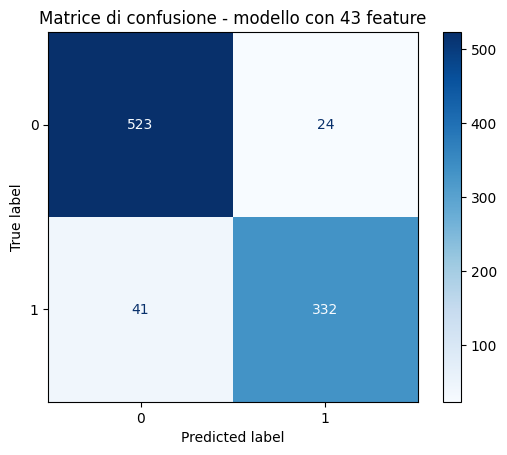

In [ ]:
random_forest = rf_models[53]
print(f"Modello selezionato (43 feature): {random_forest}")

ConfusionMatrixDisplay.from_estimator(random_forest, X_val, y_val, cmap='Blues')
plt.title("Matrice di confusione - modello con 43 feature")
plt.show()

## MLP

The final model tested is a Multi-Layer Perceptron (MLP), a type of feed-forward artificial neural network. Neural networks are renowned for their ability to model complex non-linear relationships, often obtaining the highest accuracy values in classification tasks.

However, these architectures are inherently "heavy" in terms of both computational power and memory usage. To address this challenge, our experimentation focused on designing minimalist architectures: we drastically limited the number of neurons and hidden layers.

The goal is to determine whether, despite this forced  simplification, the  network can maintain good predictive power compared to other models.

In [ ]:
mlp_params = {
    'model__hidden_layer_sizes': [(5,),(5,3)],
    'model__activation': ['logistic'],
    'model__alpha': [0.001, 0.01],
}

NN = MLPClassifier(max_iter=500)

In [ ]:
NN_results, NN_models = training(NN, mlp_params, X_train, y_train, X_val, y_val, feature_range, VERBOSE=True)

feature 1, hidden_layer_sizes = (5, 3), alpha = 0.001, F1: 0.747, Memory: 21.76


KeyboardInterrupt: 

The scatterplot analysis reveals that nearly all configurations are situated in the upper-right quadrant, indicating high accuracy but also a substantial memory usage. The model trained with 31 features emerges as the optimal solution: it achieves an F1-Score of 0.934 (the same as the 34-feature configuration) while maintaining a relatively low memory weight of only 39 KB.

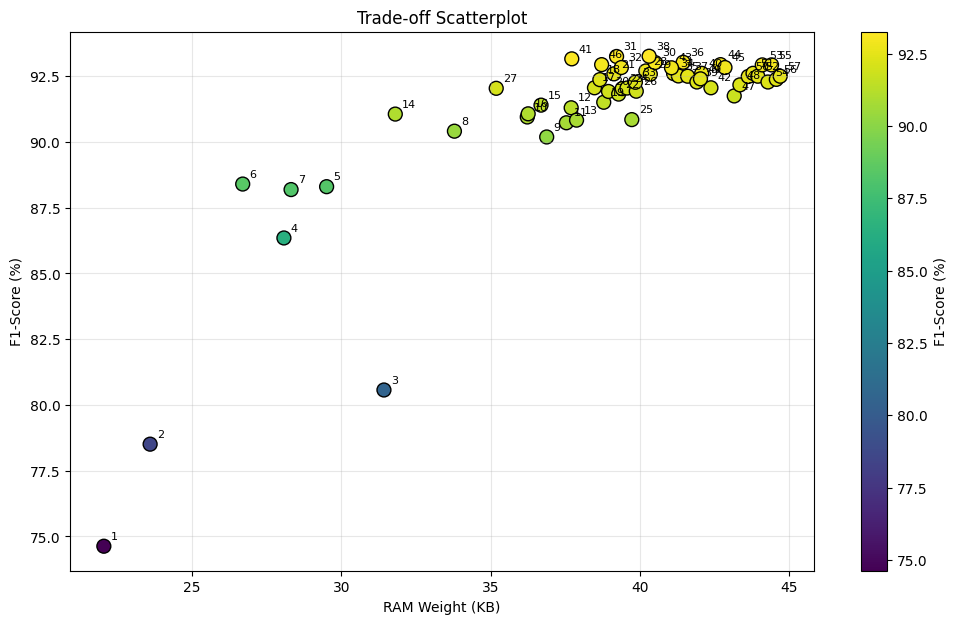


Confusion MAtrix 57 modelli:


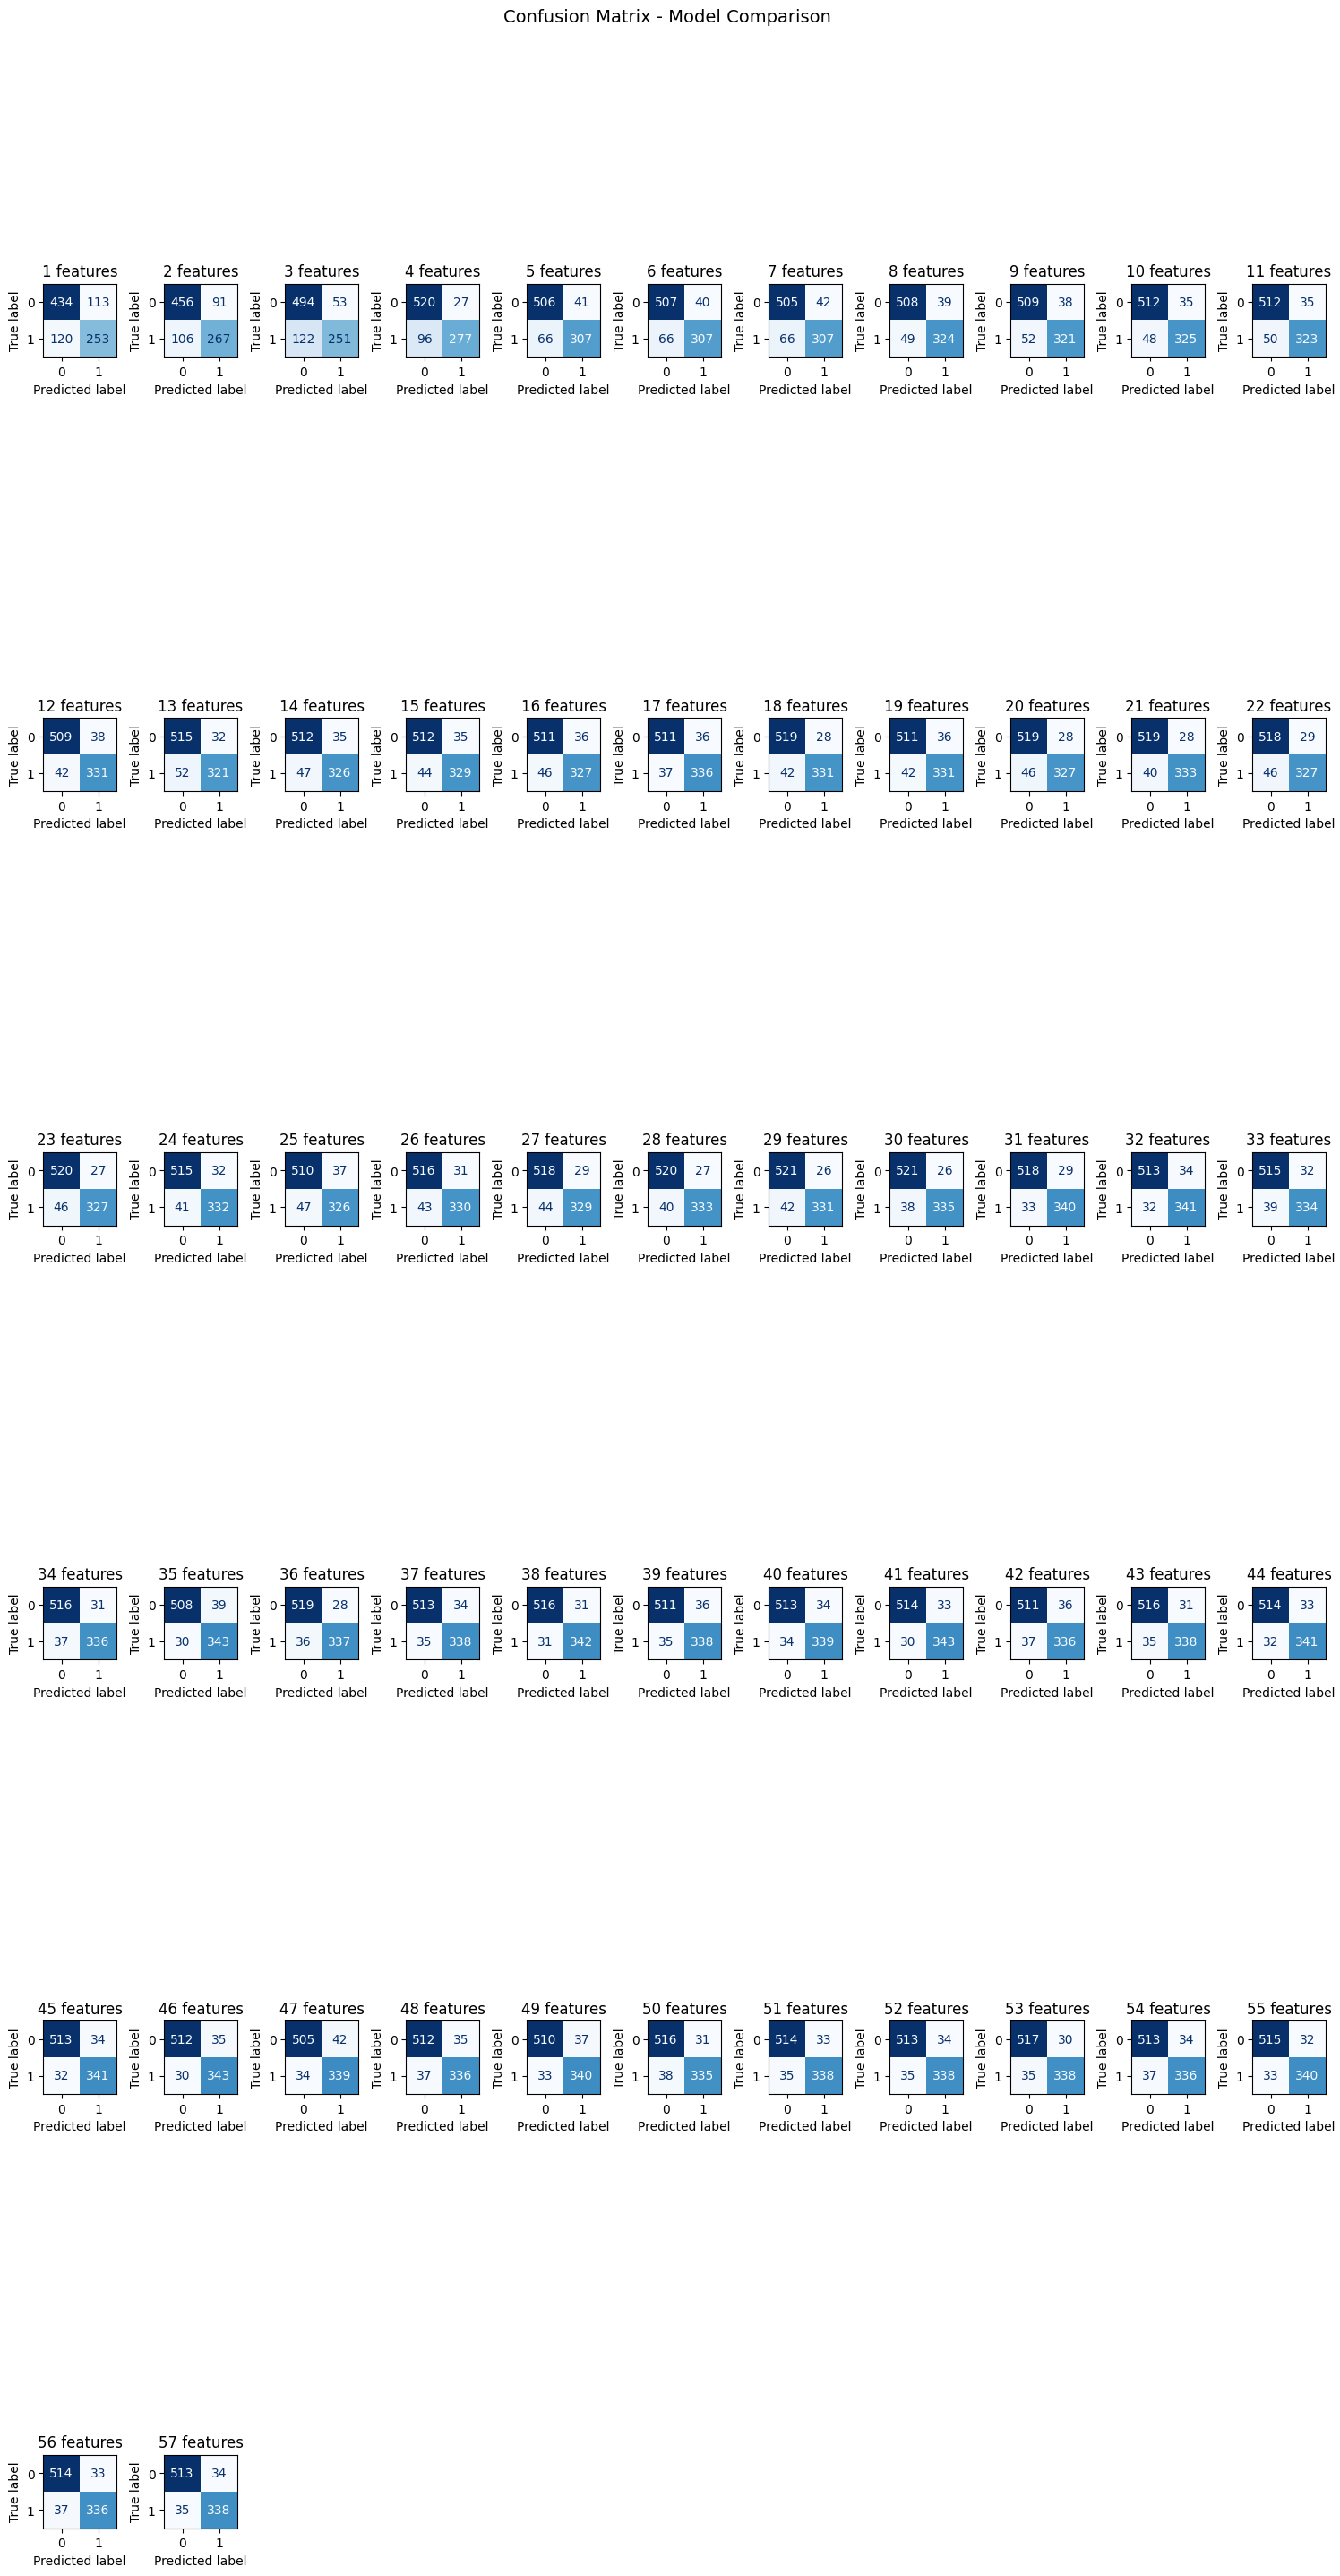

In [ ]:
scatterplot(NN_results)
confusionematrix(NN_models, X_val, y_val)

The confusion matrix for the MLP model reveals an error distribution similar to that of the Random Forest. The neural classifier records a slightly higher number of False Negatives (27 compared to 20 for the Random Forest), showing a marginally lower spam detection rate. However, the MLP proves to be more reliable regarding False Positives, reducing the count to 34 (compared to 38 for the Random Forest).

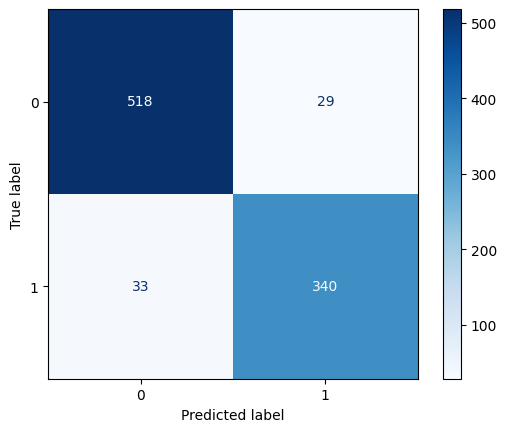

In [ ]:
NN = NN_models[31]
ConfusionMatrixDisplay.from_estimator(NN, X_val, y_val, cmap='Blues')
plt.show()

## LinearSVC

Another alternative could be the `LinearSVC` function.
This is a variant of the Support Vector Machine specifically optimized for linear kernels. While `SVC(kernel='linear')` and `LinearSVC` may appear interchangeable, they are very different

First of all they use two different libraries: LinearSVC is built upon the liblinear library, and SVC uses libsvm.

Than, LinearSVC minimizes the squared hinge loss and does not support non-linear kernels. This limitation allows it to be significantly faster and more memory-efficient during training.


In [ ]:
lin_svm_grid = {
    'model__C': [1, 3, 5, 9],
}

model_lin = LinearSVC()

In [ ]:
svm_result_lin, svm_models_lin = training(model_lin, lin_svm_grid, X_train, y_train, X_val, y_val, feature_range, VERBOSE=True)

feature 1, F1: 0.633, Memory: 8.55
feature 2, F1: 0.701, Memory: 8.6
feature 3, F1: 0.761, Memory: 8.62
feature 4, F1: 0.801, Memory: 8.66
feature 5, F1: 0.808, Memory: 8.65
feature 6, F1: 0.807, Memory: 8.63
feature 7, F1: 0.804, Memory: 8.68
feature 8, F1: 0.832, Memory: 8.7
feature 9, F1: 0.854, Memory: 8.71
feature 10, F1: 0.851, Memory: 8.76
feature 11, F1: 0.847, Memory: 8.74
feature 12, F1: 0.849, Memory: 8.76
feature 13, F1: 0.859, Memory: 8.8
feature 14, F1: 0.862, Memory: 8.79
feature 15, F1: 0.866, Memory: 8.8
feature 16, F1: 0.866, Memory: 8.82
feature 17, F1: 0.874, Memory: 8.84
feature 18, F1: 0.873, Memory: 8.85
feature 19, F1: 0.874, Memory: 8.9
feature 20, F1: 0.876, Memory: 8.88
feature 21, F1: 0.875, Memory: 8.9
feature 22, F1: 0.884, Memory: 8.95
feature 23, F1: 0.881, Memory: 8.96
feature 24, F1: 0.894, Memory: 8.98
feature 25, F1: 0.895, Memory: 8.99
feature 26, F1: 0.895, Memory: 9.01
feature 27, F1: 0.894, Memory: 8.99
feature 28, F1: 0.903, Memory: 9.04
feature

Compared to the classic non-linear SVM, LinearSVC has a drastically lower memory footprint. The most complex LinearSVC model weighs only 9.43 KB, which is significantly less than the 400 KB required by the non-linear SVM. Nevertheless, despite its compactness, LinearSVC remains more memory-intensive than a Decision Tree, although it has a significant higher F1-score.

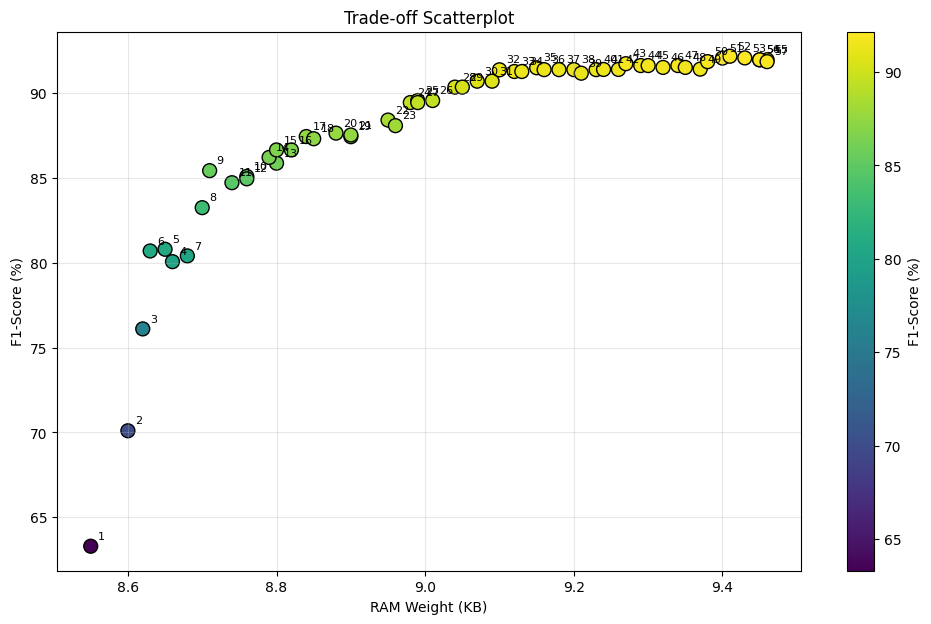


Confusion MAtrix 57 modelli:


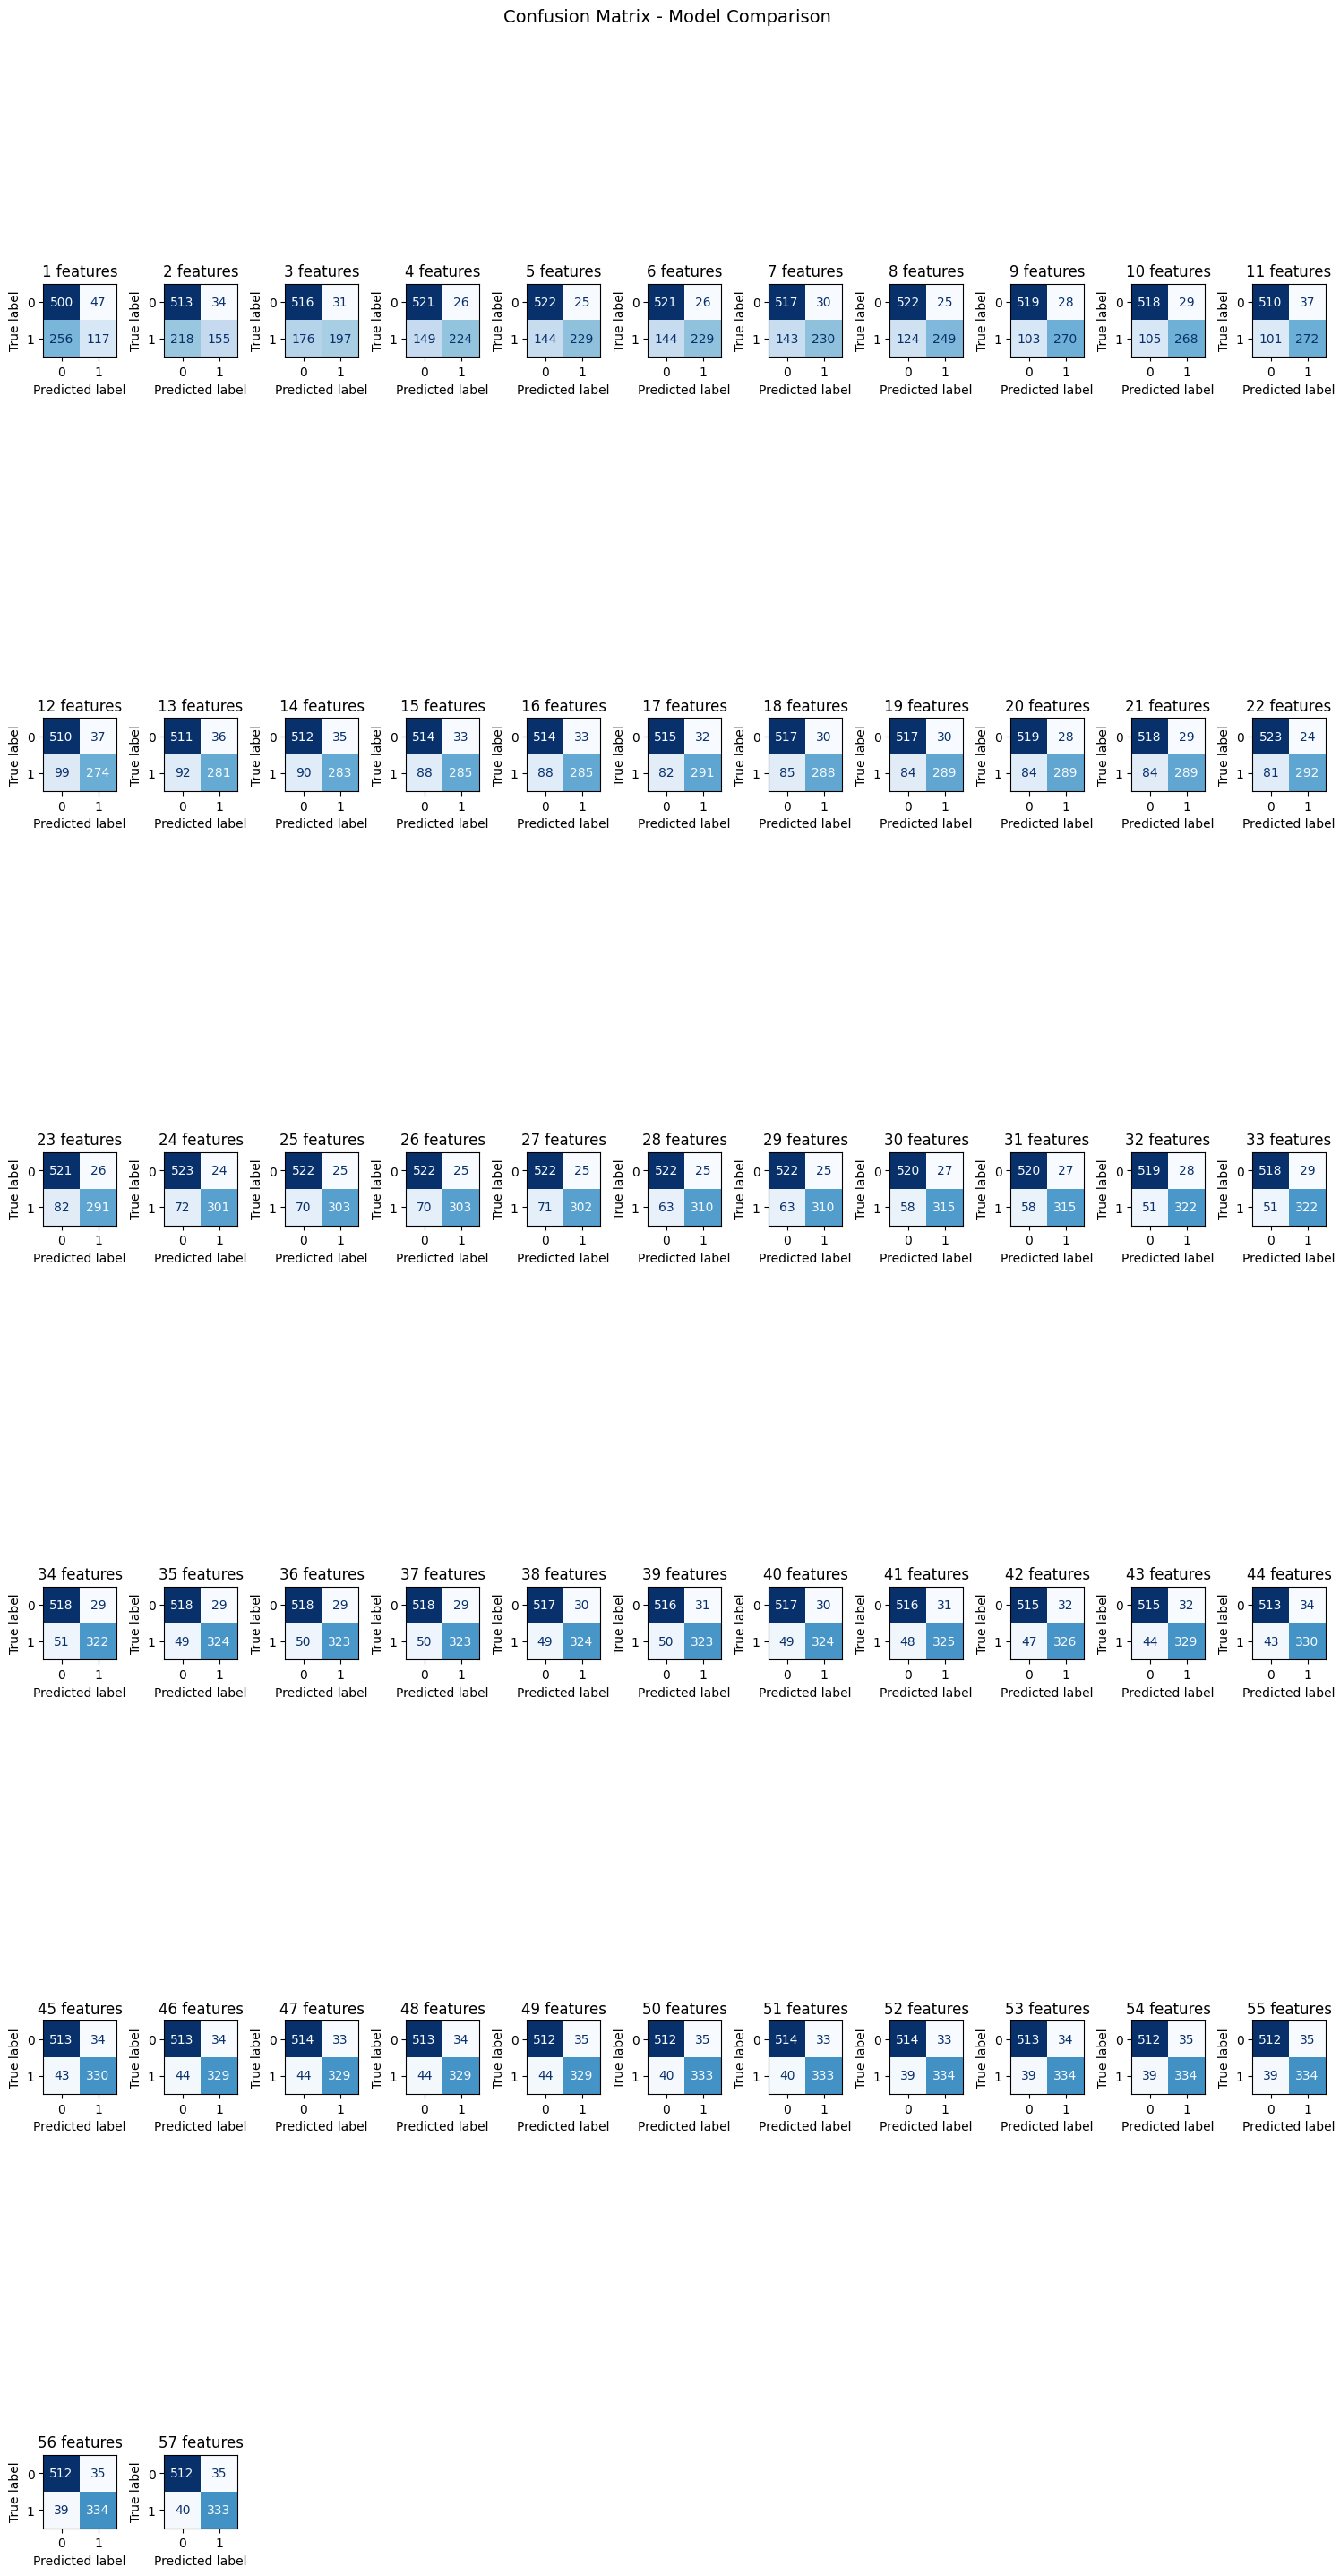

In [ ]:
scatterplot(svm_result_lin)
confusionematrix(svm_models_lin, X_val, y_val)

The confusion matrix for LinearSVC mirrors the trends observed in previous models. Specifically, it confirms a significantly higher number of false positives compared to false negatives, although the observed values in both boxes are very low.

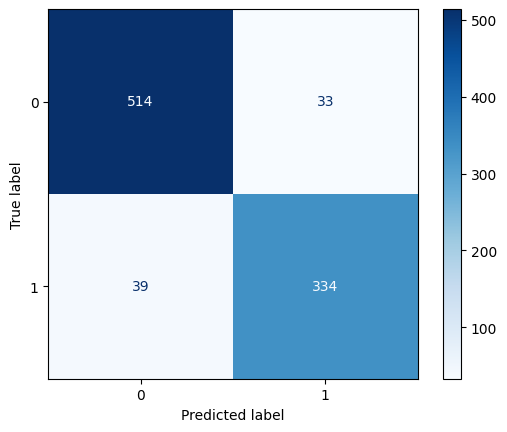

In [ ]:
svm_lin = svm_models_lin[52]

predictions = svm_lin.predict(X_val)

ConfusionMatrixDisplay.from_estimator(svm_lin, X_val, y_val, cmap='Blues')
plt.show()

## Final Evaluation

We now proceed to the comparison of the five proposed models. First, we load the best configurations for each model into a dictionary and subsequently we perform predictions on the test dataset.

In [ ]:
best_results = []
models = {'SVM': svm, 'Tree': tree, 'Random Forest': random_forest, 'NN': NN, 'SVM_lin': svm_lin}

In [ ]:
for name, m in models.items():

    predictions = m.predict(X_test)

    report = classification_report(y_test, predictions, output_dict=True)
    acc = report['accuracy']
    f1 = report['weighted avg']['f1-score']
    precision = report['weighted avg']['precision']

    size_kb = asizeof.asizeof(m) / 1024

    best_results.append({
        "Model": name,
        "Accuratezza (%)": round(acc * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "Peso (KB)": round(size_kb, 2),
    })
    print(f"model {name}, F1: {round(f1,3)}, Memory: {round(size_kb, 2)}")

model SVM, F1: 0.923, Memory: 76.77
model Tree, F1: 0.896, Memory: 8.5
model Random Forest, F1: 0.948, Memory: 45.05
model NN, F1: 0.932, Memory: 39.22
model SVM_lin, F1: 0.936, Memory: 9.41


The best model in terms of F1-score was the Random Forest, achieving a value of nearly 0.95. The second-best model by F1-score was the Linear SVM with a value of 0.936, which is very close to that of the MLP.

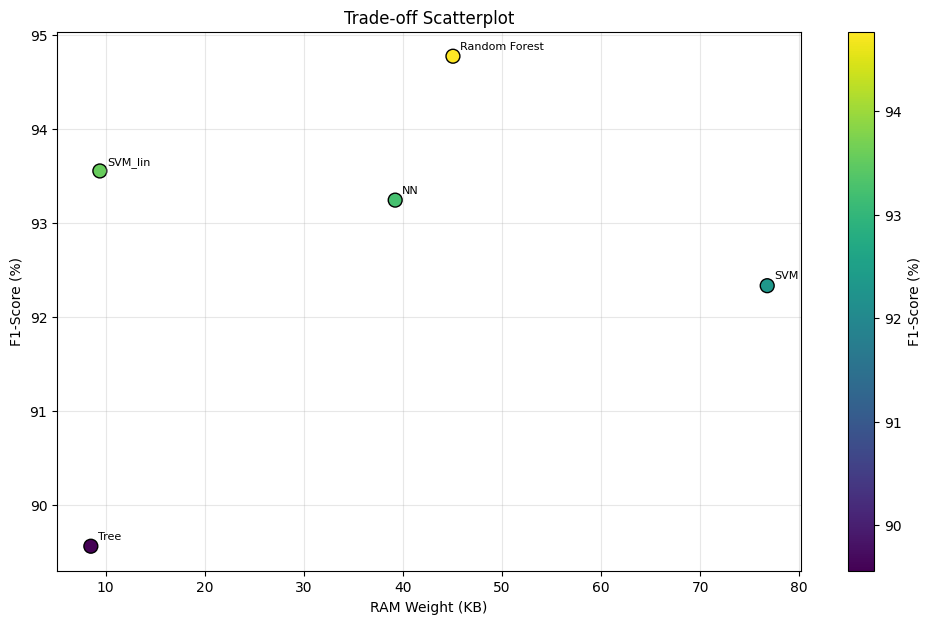


Confusion MAtrix 5 modelli:


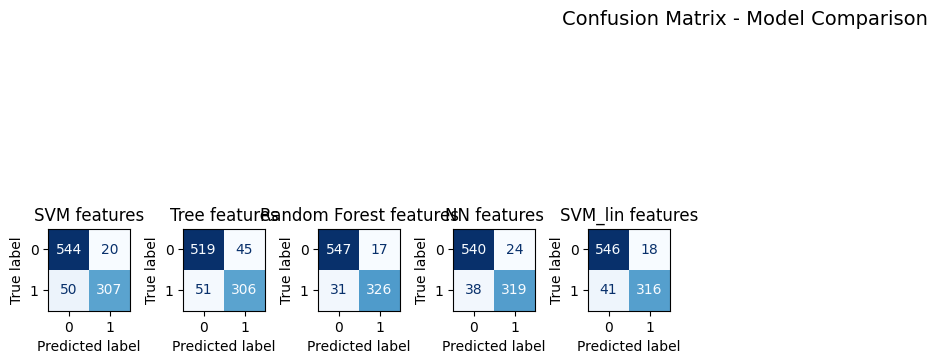

In [ ]:
scatterplot(best_results)
confusionematrix(models, X_test, y_test)

The confusion matrices confirm what was previously discussed. It can be observed that the Random Forest and the Linear SVM have the lowest number of false negatives. Interestingly, the SVM with RBF kernel has a lower number of false negatives than the MLP classifier, despite the latter having a higher F1-score. In terms of false positives, the Random Forest is the best-performing model, achieving the lowest number. The MLP classifier also performs well with 38 false positives, while the Linear SVM follows with 41 false positives.

## Conclusion

A total of five models were analyzed. The best overall model among the "heavyweight" options in terms of accuracy appears to be the Random Forest, with an F1-score of 0.948, excellent results for both false negatives and false positives, and a memory footprint of 45 KB.

Among the lightweight models, the Linear SVM and the Decision Tree, the Linear SVM is significantly better, even outperforming the MLP classifier and the SVM with an RBF kernel. The Linear SVM shows an excellent number of false negatives but a relatively high number of false positives. However, considering its memory weight of 9.4 KB, this represents a good trade-off.